<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h2 style="color:#073B74;">نگرش کاربران شبکه‌های اجتماعی درباره‌ی جنگ ایران-آمریکا</h2>
<p><strong>پروژه‌ی پایانی گروهی — خلاصه‌ی یکجای کل مسیر تحلیل</strong></p>
<p>این نوت‌بوک همه‌ی مراحل پروژه رو کنار هم میاره: جمع‌آوری داده، نمونه‌گیری، Annotation، آمار توصیفی، روند زمانی، رویدادها، تحلیل مالی و تحلیل حساسیت. کد کامل هر مرحله توی <code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">src/</code> هست و مستندات تفصیلی‌تر توی <code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">docs/</code>؛ اینجا فقط خروجی نهایی هر بخش رو با هم مرور می‌کنیم و توضیح می‌دیم چرا اون تصمیم رو گرفتیم.</p>
<p>همه‌ی سلول‌های کد این نوت‌بوک مستقیم از فایل‌های واقعی پروژه (<code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">data/</code>, <code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">outputs/</code>) می‌خونن — چیزی از پیش محاسبه یا Hardcode نشده، پس اگه دوباره اجراش کنی همیشه آخرین وضعیت رو نشون می‌ده.</p>
<p><strong>بازه‌ی مطالعه:</strong> ۹ اسفند ۱۴۰۴ تا ۳۰ مرداد ۱۴۰۵ <strong>پلتفرم‌ها:</strong> X (توییتر سابق)، Reddit، YouTube</p>
</div>

In [1]:
from pathlib import Path
import sys

def find_project_root(start=None):
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "config" / "config.yaml").exists() or (candidate / "src" / "temporal_analysis").exists():
            return candidate
    raise FileNotFoundError("Project root not found — run from within the media-sentiment-pipeline repo.")

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import json
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)

print("پروژه از این مسیر خونده می‌شه:", ROOT.name)


پروژه از این مسیر خونده می‌شه: media-sentiment-pipeline-starter


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۱. سؤال پژوهش و جامعه‌ی آماری</h3>
<p><strong>سؤال مرکزی:</strong> نگرش کاربران شبکه‌های اجتماعی نسبت به جنگ ایران و آمریکا در طول بازه‌ی پروژه چطور تغییر کرده، و چه عواملی (رویدادها، ترکیب نمونه، شاخص‌های مالی) با این تغییرات همراه بودن؟</p>
<p>چند نکته‌ی روش‌شناسی که از همون اول قفلش کردیم:</p>
<ul style="padding-inline-start:1.4em;"><li><strong>جامعه‌ی آماری، «همه‌ی مردم دنیا» یا حتی «همه‌ی کاربران این سه پلتفرم» نیست.</strong> نمونه‌ی ما غیراحتمالی (Non-probability) و مبتنی بر Query و Sourceه است — دقیقاً همون‌چیزی که در دسترس Collectorهای رایگان این پلتفرم‌ها بود. هر نتیجه‌ای که پایین‌تر میاد، فقط توصیف همین نمونه‌ی مشاهده‌شده‌ست، نه تعمیم به یک جمعیت بزرگ‌تر.</li><li><strong>Sentiment با Stance فرق داره.</strong> یک متن می‌تونه از نظر لحن منفی باشه ولی در عین حال از یک طرف دعوا حمایت کنه — پس هر دو رو جدا annotate کردیم، نه فقط یکی.</li><li><strong>سه Target اصلی</strong> برای Stance تعریف شده: <code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">T01</code> (تشدید/اقدام نظامی)، <code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">T02</code> (مذاکره و آتش‌بس)، <code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">T03</code> (تحریم و فشار اقتصادی). سه Target تکمیلی (<code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">T04</code>-<code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">T06</code>) هم هست که در صورت کیفیت کافی نمونه استفاده می‌شن.</li></ul>
</div>

<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۲. جمع‌آوری داده: چقدر و از کجا</h3>
<p>سه تا Collector مستقل (یک نفر تیم به‌ازای هر پلتفرم) داده رو جمع کردن — هرکدوم روش خودشون: X با اسکرپینگ Selenium، Reddit با ترکیب Selenium + JSON endpoint رسمی، YouTube با API رسمی (با چرخش Region/Query برای دور زدن سقف Quota روزانه‌ی رایگان). هر فایل خامی که تحویل گرفتیم توی یک Manifest ثبت شده: کی، از کجا، با چه فرمتی.</p>
</div>

In [2]:
manifest = pd.read_csv(ROOT / "docs" / "data_handoff_manifest.csv")
print(f"{len(manifest)} فایل خام تحویل گرفته‌شده و ثبت‌شده در Manifest:")
manifest[["platform", "provided_by", "file_role", "file_format", "received_at_utc"]]


19 فایل خام تحویل گرفته‌شده و ثبت‌شده در Manifest:


,platform,provided_by,file_role,file_format,received_at_utc
0,x,NaN,raw,csv,NaN
1,reddit,NaN,raw,jsonl,NaN
2,youtube,NaN,raw,csv,NaN
3,youtube,unknown,backup,jsonl,unknown
4,youtube,unknown,backup,jsonl,unknown
5,youtube,unknown,backup,jsonl,unknown
6,youtube,unknown,raw,jsonl,unknown
7,youtube,unknown,raw,jsonl,unknown
8,youtube,unknown,raw,csv,unknown
9,x,unknown,raw,xlsx,2026-08-13


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۳. از داده‌ی خام تا داده‌ی قابل‌تحلیل</h3>
<p>هر پلتفرم فرمت خام خودش رو داره، پس اول همه رو به یک Schema مشترک («raw_harmonized») نگاشت کردیم، بعد یک زنجیره‌ی قاعده‌مند از فیلترها («Eligibility») روش اجرا کردیم: اعتبارسنجی خام → حذف تکراری‌های دقیق → قاعده‌ی بازه‌ی زمانی → وجود متن → Provenance → ربط موضوعی → نقش تحلیلی. هیچ رکوردی بدون دلیل مستند حذف نمی‌شه — هرکدوم یه برچسب می‌خوره که چرا کجا رفته.</p>
</div>

In [3]:
harmonized_counts = {}
for platform in ["x", "reddit", "youtube"]:
    d = ROOT / "data" / "raw_harmonized" / platform
    n = 0
    for f in d.glob("*.parquet"):
        try:
            n += len(pd.read_parquet(f, columns=["platform"]))
        except Exception:
            pass
    harmonized_counts[platform] = n

print("رکورد خام هماهنگ‌شده (raw_harmonized) به تفکیک پلتفرم:")
for p, n in harmonized_counts.items():
    print(f"  {p:8s}: {n:>8,}")
print(f"  {'مجموع':8s}: {sum(harmonized_counts.values()):>8,}")


رکورد خام هماهنگ‌شده (raw_harmonized) به تفکیک پلتفرم:


  x       :   16,475
  reddit  :  158,959
  youtube :  157,965
  مجموع   :  333,399


In [4]:
audit = pd.read_parquet(ROOT / "data" / "audits" / "eligibility_audit.parquet")
funnel = audit["dataset_target"].value_counts()
eligible = funnel.get("opinion_main", 0) + funnel.get("opinion_limited", 0) + funnel.get("opinion_untimed", 0)

print(f"مجموع رکورد وارد Eligibility: {len(audit):,}\n")
print("نتیجه‌ی هر رکورد، به تفکیک مقصد:")
print(funnel.to_string())
print(f"\nجمع رکوردهای Eligible برای تحلیل نگرش (opinion_main + opinion_limited + opinion_untimed): {eligible:,}")


مجموع رکورد وارد Eligibility: 333,399

نتیجه‌ی هر رکورد، به تفکیک مقصد:
dataset_target
opinion_main       163192
opinion_limited    124670
quarantine          39201
audit_only           6330
opinion_untimed         6

جمع رکوردهای Eligible برای تحلیل نگرش (opinion_main + opinion_limited + opinion_untimed): 287,868


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۴. Gold Sample: روش نمونه‌گیری‌مون برای مرجع انسانی</h3>
<p>قبل از این‌که مدل زبانی رو برای Annotation کامل به‌کار بگیریم، باید یه مرجع انسانی قابل‌اعتماد می‌ساختیم که بشه کیفیت مدل رو باهاش سنجید. برای این کار <strong>۳۰۰ رکورد</strong> با نمونه‌گیری <strong>طبقه‌بندی‌شده دو بعدی</strong> (Platform × Language) و Seed ثابت (<code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">1405</code>) انتخاب شد:</p>
<ul style="padding-inline-start:1.4em;"><li><strong>۱۰۰ رکورد از هر پلتفرم</strong> (X، Reddit، YouTube) — تا هیچ پلتفرمی روی مرجع نهایی اثر نامتناسب نذاره.</li><li>داخل هر پلتفرم، سهمیه‌ی ثابت زبان: <strong>۴۵ فارسی + ۴۵ انگلیسی + ۱۰ عربی</strong>.</li><li>از این ۳۰۰ تا، یک زیرمجموعه‌ی ۱۲۰تایی رو <strong>دو نفر جدا از هم</strong> annotate کردن (برای سنجش توافق بین‌حاشیه‌نویس).</li></ul>
<p>هر دو annotator با یک Codebook مشترک کار کردن (تعریف دقیق هر کلاس Sentiment/Stance/Emotion/Content-type)، نه فقط با برداشت شخصی.</p>
</div>

In [5]:
gold = pd.read_csv(ROOT / "data" / "annotated" / "sample_sentiment_labels.csv", encoding="utf-8-sig")
print(f"حجم کل Gold Sample: {len(gold)} رکورد\n")
pd.crosstab(gold["platform"], gold["language"], margins=True, margins_name="جمع")


حجم کل Gold Sample: 300 رکورد



language,ar,en,fa,جمع
platform,,,,
reddit,10,80,10,100
x,0,45,55,100
youtube,10,45,45,100
جمع,20,170,110,300


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۵. توافق بین دو Annotator</h3>
<p>روی همون ۱۲۰ رکورد double-annotated، توافق دو annotator رو با <strong>Cohen's Kappa</strong> سنجیدیم (نه فقط درصد توافق ساده، چون اون به‌تنهایی گمراه‌کننده‌ست — با شانس هم می‌شه درصد بالایی گرفت).</p>
</div>

In [6]:
with open(ROOT / "outputs" / "audits" / "annotator_agreement.json", encoding="utf-8") as f:
    agreement = json.load(f)

rows = []
for axis, r in agreement.items():
    rows.append({
        "محور": axis.replace("_label", ""),
        "n مقایسه‌شده": r["n_compared"],
        "Cohen's Kappa": round(r["cohens_kappa"], 3),
        "درصد توافق": f'{r["percent_agreement"]:.1%}',
    })
pd.DataFrame(rows)


,محور,n مقایسه‌شده,Cohen's Kappa,درصد توافق
0,sentiment,120,0.584,75.0%
1,stance,120,0.521,64.2%
2,emotion,120,0.458,66.7%
3,content_type,120,0.648,83.3%


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۶. انتخاب مدل برای Annotation</h3>
<p>سه Route مدل/Provider مختلف (هرکدوم رایگان یا خیلی ارزون) رو دقیقاً روی همون ۳۰۰ رکورد Gold Sample تست کردیم و کنار هم گذاشتیم — نه فقط روی چند نمونه‌ی دستچین‌شده. معیار انتخاب: ترکیب Macro-F1، نرخ خطا، Coverage و هزینه، نه فقط ارزون‌ترین یا فقط دقیق‌ترین.</p>
</div>

In [7]:
with open(ROOT / "outputs" / "model_evaluation" / "sentiment_accuracy_summary.json", encoding="utf-8") as f:
    model_eval = json.load(f)

rows = []
for route, r in model_eval["routes"].items():
    rows.append({
        "Route": route,
        "Coverage": f'{r["coverage"]:.1%}',
        "نرخ خطا": f'{r["failure_rate"]:.1%}',
        "هزینه/۱۰۰۰ رکورد ($)": round(r["cost_per_1000_records_usd"], 3),
        "Sentiment Macro-F1": round(r["sentiment"]["macro_f1"], 3),
        "Stance Macro-F1": round(r["stance"]["macro_f1"], 3),
    })
df_models = pd.DataFrame(rows).sort_values("Sentiment Macro-F1", ascending=False)
df_models


,Route,Coverage,نرخ خطا,هزینه/۱۰۰۰ رکورد ($),Sentiment Macro-F1,Stance Macro-F1
2,openrouter_gemini_flash_lite,99.3%,0.0%,0.107,0.609,0.502
1,groq_default,98.7%,0.0%,0.495,0.510,0.386
0,groq_cheap_fast,100.0%,0.0%,0.043,0.377,0.349


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<p>مدل انتخاب‌شده (<code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">openrouter_gemini_flash_lite</code>) روی هیچ معیاری از بقیه شکست نمی‌خوره: بالاترین کیفیت روی هر دو محور، صفر خطا، Coverage تقریباً کامل، و هزینه‌ی میانه (نه گرون‌ترین). این انتخاب و تنظیماتش، طبق قاعده‌ی پروژه، بعد از این Pilot قفل شد و دیگه در طول Full Annotation عوض نشد.</p>
</div>

<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۷. Annotation کامل: مقیاس‌دادن بدون بودجه</h3>
<p>طبق تعریف اولیه‌ی پروژه، کل کار باید <strong>بدون بودجه</strong> پیش می‌رفت — یعنی annotate‌کردن مدل زبانی روی چیزی حدود ۲۸۰ هزار رکورد Eligible باید فقط با حساب‌های رایگان یا کم‌هزینه‌ی شخصی اعضای تیم انجام می‌شد، نه یک حساب شرکتی پرسرعت.</p>
<p>برای اینکه از پس این محدودیت واقعی بربیایم:</p>
<ul style="padding-inline-start:1.4em;"><li>annotation رو روی <strong>۱۱ تا API Key شخصی</strong> (چند حساب Groq و OpenRouter، هرکدوم مال یکی از اعضای تیم) پخش کردیم و بین‌شون Rotate کردیم — هروقت یه کلید به سقف روزانه‌ش می‌رسید، خودکار می‌رفت سراغ کلید بعدی.</li><li>به‌جای اینکه یه تکه‌ی تصادفی و بی‌قاعده از داده رو annotate کنیم (که ممکن بود یه هفته یا پلتفرم خاص کلاً بی‌نصیب بمونه)، از یک <strong>نمونه‌گیری طبقه‌بندی‌شده روی Platform × Week</strong> استفاده کردیم — سقف ۱۲۰ رکورد به‌ازای هر سلول (پلتفرم × هفته)، با همون Seed ثابت (<code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">1405</code>). این‌طوری مطمئنیم هر هفته و هر پلتفرمی که داده‌ی کافی داشته، حداقل یه نمونه‌ی معنادار (n≥۳۰، در واقع تا ۱۲۰) براش annotate شده — نه فقط چندتا هفته‌ی اول.</li></ul>
<p>annotation کامل روی کل داده و هر ۶ Target، فراتر از بازه‌ی این تحویل، ادامه پیدا می‌کنه.</p>
</div>

In [8]:
ann = pd.read_parquet(ROOT / "data" / "processed" / "annotated_dataset.parquet")
status_counts = ann["annotation_status"].value_counts()
print(f"مجموع ردیف در annotated_dataset (هر رکورد تا ۳ بار، یکی به‌ازای هر Target اصلی): {len(ann):,}\n")
print(status_counts.to_string())

ok = ann[ann["annotation_status"] == "ok"]
print(f"\nبه تفکیک پلتفرم، رکوردهای واقعاً annotate‌شده (annotation_status=ok):")
print(ok["platform"].value_counts().to_string())


مجموع ردیف در annotated_dataset (هر رکورد تا ۳ بار، یکی به‌ازای هر Target اصلی): 234,855

annotation_status
pending_annotation    217730
ok                      9405
api_failure             7690
validation_failure        30

به تفکیک پلتفرم، رکوردهای واقعاً annotate‌شده (annotation_status=ok):
platform
reddit     4486
x          2519
youtube    2400


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۸. آمار توصیفی</h3>
<p>آمار زیر فقط روی همون بخشی از داده‌ست که تا این لحظه annotate شده (بالا) — یعنی توصیف یک نمونه‌ی طبقه‌بندی‌شده از کل دیتاسته، نه کل دیتاست.</p>
</div>

In [9]:
desc = pd.read_csv(ROOT / "outputs" / "tables" / "descriptive_stats_overall.csv", encoding="utf-8-sig")
desc.T


,0
group,overall
n_total,234855
n_annotation_ok,9405
n_annotation_non_ok,225450
pct_annotation_non_ok,96.0
n_opinion_untimed,6
n_unique_content_id,233006
n_unique_text_raw,227525
n_unique_parent_id,75831
n_unique_post_id,151267


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۹. روند هفتگی نگرش‌ها</h3>
<p>برای هر هفته و هر پلتفرم، سهم هر کلاس Sentiment رو همراه با <strong>فاصله‌ی اطمینان ۹۵٪ Wilson</strong> گزارش کردیم (نه فقط یه عدد خام بدون incertitude) — هفته‌هایی با نمونه‌ی کم (<code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">n&lt;30</code>) صریحاً علامت‌گذاری شدن، و W21 (پنج‌روزه و ناقص) هم جدا مشخصه.</p>
</div>

In [10]:
weekly = pd.read_csv(ROOT / "outputs" / "tables" / "weekly_trend_sentiment_by_platform.csv", encoding="utf-8-sig")
weekly.head(12)


,platform,project_week,class_label,n,class_count,class_proportion,wilson_ci_low,wilson_ci_high,is_low_sample,is_partial_week,is_data_gap
0,x,W01,positive,120,9,0.0750,0.0400,0.1364,False,False,False
1,x,W01,negative,120,96,0.8000,0.7196,0.8618,False,False,False
2,x,W01,neutral,120,15,0.1250,0.0772,0.1960,False,False,False
3,x,W01,mixed,120,0,0.0000,0.0000,0.0310,False,False,False
4,x,W01,unclear,120,0,0.0000,0.0000,0.0310,False,False,False
5,x,W02,positive,120,5,0.0417,0.0179,0.0938,False,False,False
6,x,W02,negative,120,97,0.8083,0.7288,0.8687,False,False,False
7,x,W02,neutral,120,18,0.1500,0.0970,0.2247,False,False,False
8,x,W02,mixed,120,0,0.0000,0.0000,0.0310,False,False,False
9,x,W02,unclear,120,0,0.0000,0.0000,0.0310,False,False,False


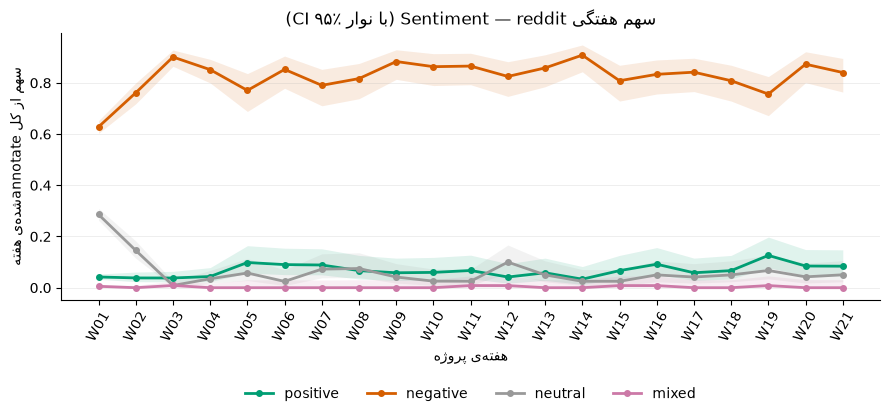

In [11]:
import matplotlib.pyplot as plt

# رنگ‌های ثابت و از قبل تعیین‌شده برای هر کلاس Sentiment (Okabe-Ito، امن برای کوررنگی)
SENTIMENT_COLORS = {
    "positive": "#009E73",  # سبز
    "negative": "#D55E00",  # قرمز آجری
    "neutral":  "#999999",  # خاکستری
    "mixed":    "#CC79A7",  # صورتی
}

platform_to_plot = "reddit"  # پرحجم‌ترین پلتفرم در Gold/annotation فعلی
subset = weekly[weekly["platform"] == platform_to_plot].copy()
subset = subset.sort_values("project_week")

fig, ax = plt.subplots(figsize=(9, 4.5))
for label, color in SENTIMENT_COLORS.items():
    line = subset[subset["class_label"] == label].sort_values("project_week")
    if line.empty:
        continue
    ax.plot(line["project_week"], line["class_proportion"], label=label, color=color, linewidth=2, marker="o", markersize=4)
    ax.fill_between(line["project_week"], line["wilson_ci_low"], line["wilson_ci_high"], color=color, alpha=0.12, linewidth=0)

ax.set_title(f"سهم هفتگی Sentiment — {platform_to_plot} (با نوار CI ۹۵٪)")
ax.set_ylabel("سهم از کل annotate‌شده‌ی هفته")
ax.set_xlabel("هفته‌ی پروژه")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.tick_params(axis="x", rotation=60)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.28))
fig.tight_layout()
plt.show()


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۱۰. تغییر ترکیب نمونه در طول زمان (Composition Shift)</h3>
<p>قبل از این‌که یه تغییر توی روند رو به «تغییر نگرش واقعی» نسبت بدیم، باید مطمئن بشیم ناشی از تغییر <strong>ترکیب</strong> نمونه نیست (مثلاً یهو سهم یه پلتفرم یا یه زبان زیاد شده). این جدول دقیقاً همینو نشون می‌ده.</p>
</div>

In [12]:
comp = pd.read_csv(ROOT / "outputs" / "tables" / "composition_shift_platform_share.csv", encoding="utf-8-sig")
comp.pivot(index="project_week", columns="platform", values="platform_share").round(3)


platform,reddit,x,youtube
project_week,,,
W01,0.858,0.071,0.071
W02,0.636,0.182,0.182
W03,0.611,0.212,0.176
W04,0.512,0.266,0.222
W05,0.338,0.330,0.332
W06,0.338,0.330,0.332
W07,0.432,0.418,0.150
W08,0.334,0.332,0.334
W09,0.333,0.333,0.333


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۱۱. مقایسه‌ی آماری بین گروه‌ها</h3>
<p>هر آزمون آماری همراه با Effect Size و فاصله‌ی اطمینانشه — نه فقط p-value؛ طبق قاعده‌ی خودمون، حتی نتایج غیرمعنادار یا <code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">not_applicable</code> (مثلاً وقتی یه فیلد برای یه پلتفرم اصلاً پر نشده) هم گزارش می‌شن، نه فقط مواردی که p&lt;۰.۰۵ شدن.</p>
</div>

In [13]:
gc = pd.read_csv(ROOT / "outputs" / "tables" / "group_comparison_results.csv", encoding="utf-8-sig")
gc[["comparison_id", "question", "test", "effect_size_type", "n", "effect_size", "p_value"]]


,comparison_id,question,test,effect_size_type,n,effect_size,p_value
0,chi_square_stance_platform,توزیع Stance بین پلتفرم‌ها متفاوت است؟,chi_square,cramers_v,9405,0.146827,1.243065e-82
1,chi_square_stance_language,توزیع Stance بین زبان‌ها متفاوت است؟,chi_square,cramers_v,9405,0.103948,4.455678e-58
2,fisher_x_vs_reddit,support/oppose نسبت متفاوت بین x و reddit؟ (جدول ۲×۲),fisher_exact,odds_ratio,5385,0.850869,1.374316e-01
3,mannwhitney_engagement_x_vs_reddit,Engagement متفاوت بین x و reddit؟,mann_whitney_u,rank_biserial_r,0,NaN,NaN
4,welch_text_length_x_vs_reddit,میانگین طول متن متفاوت بین x و reddit؟,welch_t_test,hedges_g,168288,-0.017990,1.407000e-08
5,fisher_x_vs_youtube,support/oppose نسبت متفاوت بین x و youtube؟ (جدول ۲×۲),fisher_exact,odds_ratio,4146,0.525503,3.204855e-09
6,mannwhitney_engagement_x_vs_youtube,Engagement متفاوت بین x و youtube؟,mann_whitney_u,rank_biserial_r,0,NaN,NaN
7,welch_text_length_x_vs_youtube,میانگین طول متن متفاوت بین x و youtube؟,welch_t_test,hedges_g,82359,0.538896,0.000000e+00
8,fisher_reddit_vs_youtube,support/oppose نسبت متفاوت بین reddit و youtube؟ (جدول ۲×۲),fisher_exact,odds_ratio,5333,0.617607,2.814935e-07
9,mannwhitney_engagement_reddit_vs_youtube,Engagement متفاوت بین reddit و youtube؟,mann_whitney_u,rank_biserial_r,0,NaN,NaN


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۱۲. اثر رویدادهای کلیدی (Event Study)</h3>
<p>برای رویدادهای از‌پیش‌ثبت‌شده (نه انتخاب‌شده بعد از دیدن Spike، که Cherry-picking می‌شه)، سهم Stance رو دو هفته قبل و دو هفته بعد مقایسه کردیم. نتیجه همیشه <strong>«همراهی زمانی»</strong> گزارش می‌شه، نه اثر علّی — این داده برای اثبات علیت طراحی نشده.</p>
</div>

In [14]:
events = pd.read_csv(ROOT / "outputs" / "tables" / "event_analysis" / "event_study_main.csv", encoding="utf-8-sig")
events[events["is_placebo"] == False][
    ["event_id", "title_fa", "platform", "target_id", "p_before", "p_after", "share_diff", "n_before_target", "n_after_target"]
]


,event_id,title_fa,platform,target_id,p_before,p_after,share_diff,n_before_target,n_after_target
0,EV-016,اعلام آتش‌بس دوهفته‌ای,x,T02,NaN,NaN,NaN,0,0
1,EV-016,اعلام آتش‌بس دوهفته‌ای,reddit,T02,0.046512,0.000000,-0.046512,43,3
2,EV-016,اعلام آتش‌بس دوهفته‌ای,youtube,T02,NaN,NaN,NaN,0,0
3,EV-025,امضای تفاهم‌نامه اسلام‌آباد,x,T02,NaN,NaN,NaN,0,0
4,EV-025,امضای تفاهم‌نامه اسلام‌آباد,reddit,T02,NaN,NaN,NaN,0,0
5,EV-025,امضای تفاهم‌نامه اسلام‌آباد,youtube,T02,NaN,NaN,NaN,0,0
6,EV-031,ازسرگیری حملات متقابل,x,T01,0.741667,0.725000,-0.016667,120,120
7,EV-031,ازسرگیری حملات متقابل,reddit,T01,0.850000,0.816667,-0.033333,120,120
8,EV-031,ازسرگیری حملات متقابل,youtube,T01,0.850000,0.658333,-0.191667,120,120


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۱۳. رابطه با شاخص‌های مالی</h3>
<p>چهار شاخص اصلی (نفت برنت، طلا، VIX، نرخ دلار آزاد ایران) رو با شاخص‌های هفتگی نگرش هم‌تراز کردیم و همبستگی Spearman با Lag صفر تا دو هفته گرفتیم — با اصلاح Benjamini-Hochberg برای آزمون‌های متعدد. اینجا هم رابطه، <strong>همبستگی اکتشافی</strong> گزارش می‌شه، نه رابطه‌ی علّی.</p>
</div>

In [15]:
fin = pd.read_csv(ROOT / "outputs" / "tables" / "financial" / "financial_social_correlation_results_v1.csv", encoding="utf-8-sig")
primary = fin[(fin["test_family"] == "primary_spearman") & (fin["financial_lag_weeks"] == 0)]
primary[["platform", "outcome_id", "asset_id", "n_paired_weeks", "coefficient", "p_value_raw", "p_value_bh_fdr", "status"]].sort_values("p_value_bh_fdr").head(15)


,platform,outcome_id,asset_id,n_paired_weeks,coefficient,p_value_raw,p_value_bh_fdr,status
66,reddit,negative_sentiment_share,VIX,21,0.304644,0.1805,0.85608,exploratory_association_not_causal
48,reddit,negative_sentiment_share,GOLD_USD,21,-0.329977,0.1456,0.85608,exploratory_association_not_causal
90,reddit,oppose_share,VIX,21,0.361211,0.1094,0.85608,exploratory_association_not_causal
72,reddit,oppose_share,GOLD_USD,21,-0.294176,0.1997,0.85608,exploratory_association_not_causal
108,reddit,support_share,OIL_BRENT,21,0.540489,0.0120,0.85608,exploratory_association_not_causal
228,x,oppose_share,OIL_BRENT,21,0.417213,0.0593,0.85608,exploratory_association_not_causal
204,x,negative_sentiment_share,OIL_BRENT,21,0.446616,0.0406,0.85608,exploratory_association_not_causal
126,reddit,unclear_share,IRR_USD,21,0.272671,0.2286,0.85608,exploratory_association_not_causal
300,youtube,anger_share,OIL_BRENT,21,-0.284228,0.2080,0.85608,exploratory_association_not_causal
390,youtube,support_share,IRR_USD,21,-0.268969,0.2315,0.85608,exploratory_association_not_causal


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۱۴. تحلیل حساسیت</h3>
<p>قبل از این‌که به هیچ نتیجه‌ای زیادی تکیه کنیم، حداقل ۶ مقایسه‌ی حساسیت انجام دادیم: با/بدون Duplicate، Content-level در برابر Author-balanced، با/بدون بزرگ‌ترین Source یا Parent، Confidence بالا در برابر همه، و Engagement-weighted در برابر Unweighted.</p>
</div>

In [16]:
sens = pd.read_csv(ROOT / "outputs" / "tables" / "sensitivity_analysis_results.csv", encoding="utf-8-sig")
sens[["comparison_id", "platform", "n_baseline", "positive_share_baseline", "n_alternative", "positive_share_alternative", "shift"]]


,comparison_id,platform,n_baseline,positive_share_baseline,n_alternative,positive_share_alternative,shift
0,duplicate_inclusion,x,2519,0.075824,2401,0.075385,-0.000438
1,duplicate_inclusion,reddit,4486,0.055506,4346,0.056604,0.001098
2,duplicate_inclusion,youtube,2400,0.241667,2323,0.235041,-0.006626
3,content_vs_author_balanced,x,2519,0.075824,1884,0.080117,0.004293
4,content_vs_author_balanced,reddit,4486,0.055506,3054,0.061161,0.005655
5,content_vs_author_balanced,youtube,2400,0.241667,2077,0.239881,-0.001786
6,largest_source_exclusion,x,2519,0.075824,0,NaN,NaN
7,largest_source_exclusion,reddit,4486,0.055506,3719,0.054585,-0.000921
8,largest_source_exclusion,youtube,2400,0.241667,1793,0.264919,0.023252
9,largest_parent_exclusion,x,2519,0.075824,0,NaN,NaN


<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۱۵. ادعاهای نهایی</h3>
<p>هر ادعا اینجا مستقیم به یه فایل/ردیف مشخص Reference می‌شه — نه یه جمله‌ی کلی بی‌مرجع. لیست کامل‌تر و به‌روز توی <code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">docs/claim_registry.md</code> نگهداری می‌شه.</p>
<table style="direction:rtl; text-align:right; border-collapse:collapse; width:100%;">
<thead><tr><th style="border-bottom:2px solid #073B74; padding:6px 10px;">#</th><th style="border-bottom:2px solid #073B74; padding:6px 10px;">ادعا</th><th style="border-bottom:2px solid #073B74; padding:6px 10px;">مرجع</th><th style="border-bottom:2px solid #073B74; padding:6px 10px;">محدودیت</th></tr></thead><tbody>
<tr><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">C01</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">توزیع Stance بین سه پلتفرم تفاوت آماری معنادار دارد (Cramér's V=۰.۱۴۷)</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;"><code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">group_comparison_results.csv</code></td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">فقط روی بخش annotate‌شده؛ همراهی نه علیت</td></tr>
<tr><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">C02</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">طول متن بین X و YouTube تفاوت معنادار دارد (Hedges' g≈۰.۵)</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;"><code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">group_comparison_results.csv</code></td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">Effect size متوسط</td></tr>
<tr><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">C03</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">حذف Duplicate/Near-duplicate سهم Sentiment مثبت را معنادار جابه‌جا نمی‌کند</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;"><code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">sensitivity_analysis_results.csv</code></td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">فقط روی نمونه‌ی annotate‌شده‌ی فعلی</td></tr>
<tr><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">C04</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">Engagement-weighting سهم مثبت YouTube را افزایش می‌دهد</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;"><code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">sensitivity_analysis_results.csv</code></td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">فقط YouTube (تنها پلتفرم با Engagement واقعی)</td></tr>
<tr><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">C05</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">داده‌ی X نه مفهوم Source (کانال) دارد، نه Parent مستقل</td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;"><code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">sensitivity_analysis_results.csv</code></td><td style="border-bottom:1px solid #dde3ea; padding:6px 10px;">محدودیت ساختاری خودِ پلتفرم X، نه محدودیت آماری ما</td></tr>
</tbody></table>
<p>هر ادعای بعدی که به گزارش نهایی اضافه بشه، باید همین قالب (ادعا → مرجع دقیق → محدودیت) رو رعایت کنه.</p>
</div>

<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">۱۶. محدودیت‌ها و مسیر ادامه</h3>
<ul style="padding-inline-start:1.4em;"><li><strong>نمونه غیراحتمالیه.</strong> هیچ‌جای این نوت‌بوک از عباراتی مثل «افکار عمومی جهان» یا «همه‌ی کاربران» استفاده نشده و نباید بشه — فقط توصیف نمونه‌ی مشاهده‌شده‌ست.</li><li><strong>Annotation کامل هنوز در حال گسترشه.</strong> با ۱۱ کلید API رایگان/کم‌هزینه، الان بخش قابل‌توجهی از داده annotate شده (بخش ۷)؛ تکمیل annotation کل داده و افزودن Target‌های تکمیلی (<code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">T04</code>-<code style="direction:ltr; unicode-bidi:embed; font-family:ui-monospace,Consolas,'DejaVu Sans Mono',monospace; background:#eef1f4; border-radius:4px; padding:0.1em 0.4em; font-size:0.9em;">T06</code>)، خارج از بازه‌ی این تحویل، ادامه پیدا می‌کنه — نه به این معنی که چیزی نادیده گرفته شده، بلکه یه تصمیم آگاهانه برای مدیریت منابع محدود بود که با نمونه‌گیری طبقه‌بندی‌شده (بخش ۷) جبران شد.</li><li><strong>کیفیت مدل کامل نیست.</strong> Macro-F1 مدل انتخاب‌شده روی Sentiment حدود ۰.۶۱ و روی Stance حدود ۰.۵۰ است (بخش ۶) — یعنی annotation خودکار خطا داره، نه یک مرجع قطعی.</li><li><strong>همبستگی، علیت نیست.</strong> هم رابطه با شاخص‌های مالی و هم اثر رویدادها، به‌عنوان «همراهی زمانی» گزارش شدن، نه رابطه‌ی علّی اثبات‌شده.</li><li><strong>Engagement فقط برای YouTube کامله</strong> — X و Reddit این فیلد رو پر نمی‌کنن، پس مقایسه‌های وزن‌دار به Engagement فقط برای YouTube معناداره.</li><li><strong>پوشش زبان نامتوازنه</strong> (فارسی/انگلیسی بیشتر از عربی) — دقیقاً طبق سهمیه‌ی از‌پیش‌تعیین‌شده‌ی Gold Sample (بخش ۴)، ولی همچنان یه محدودیت واقعیه که باید در تفسیر نتایج در نظر گرفته بشه.</li></ul>
</div>

<div dir="rtl" style="direction:rtl; text-align:right; font-family:Vazirmatn, Tahoma, Arial, sans-serif; line-height:1.9;">
<h3 style="color:#073B74;">جمع‌بندی</h3>
<p>از جمع‌آوری بیش از سیصد هزار رکورد خام از سه پلتفرم، تا Eligibility، Gold Sample، انتخاب و ارزیابی مدل annotation، و تحلیل‌های توصیفی/زمانی/رویدادی/مالی/حساسیت — همه‌ی مراحل این پروژه با مستندسازی کامل (Manifest، Decision Log، Claim Registry) پیش رفته، طوری که هر عدد قابل ردیابی به یک فایل مشخصه. ادامه‌ی طبیعی این کار، تکمیل annotation روی کل داده‌ی Eligible و گسترش تحلیل به Targetهای تکمیلیه.</p>
</div>